✅ Loaded Data. Shape: (4591, 12)
📊 Training Tensors: torch.Size([3660, 12, 5])
📊 Testing Tensors:  torch.Size([907, 12, 5])

🧠 Model Architecture Created:
VolatilityLSTM(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

🏋️‍♂️ Starting Training...
Epoch [10/50], Train Loss: 0.016089, Test Loss: 0.009284
Epoch [20/50], Train Loss: 0.014714, Test Loss: 0.005396
Epoch [30/50], Train Loss: 0.012660, Test Loss: 0.006608
Epoch [40/50], Train Loss: 0.008566, Test Loss: 0.003105
Epoch [50/50], Train Loss: 0.007037, Test Loss: 0.001853
💾 Model saved to c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Machine Learning & Deep Learning in Finance\NLP for Intraday Volatility Prediction\models
📊 Loss plot saved to images/training_loss.png


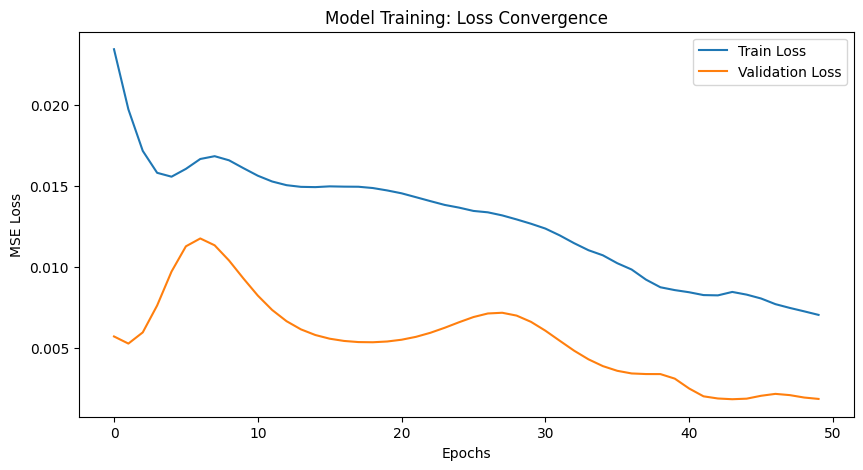

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from pathlib import Path

# ==========================================
# 1. CONFIG & DATA LOAD
# ==========================================
REQUIRED_FOLDERS = ['data', 'code', 'models', 'images', 'output']
def get_project_root():
    current_path = Path.cwd()
    if current_path.name in REQUIRED_FOLDERS: return current_path.parent
    return current_path

BASE_PATH = get_project_root()
DATA_PATH = BASE_PATH / 'data'
MODEL_PATH = BASE_PATH / 'models'

# Load Data
df = pd.read_csv(DATA_PATH / 'final_dataset_ready.csv')

# Drop rows where target is NaN (usually the last row)
df.dropna(subset=['target_volatility'], inplace=True)

# Select Features
feature_cols = ['log_return', 'rolling_volatility', 'volume', 'sentiment_pos', 'sentiment_neg']
target_col = 'target_volatility'

print(f"Loaded Data. Shape: {df.shape}")

# ==========================================
# 2. PREPROCESSING (SCALING & SPLIT)
# ==========================================
# LSTM is sensitive to scale. We normalize everything to [0, 1]
scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

# Fit scaler on inputs and target
X_raw = scaler_features.fit_transform(df[feature_cols])
y_raw = scaler_target.fit_transform(df[[target_col]])

# Time Series Split (No Shuffle!)
# 80% Train, 20% Test
train_size = int(len(df) * 0.8)
X_train_raw, X_test_raw = X_raw[:train_size], X_raw[train_size:]
y_train_raw, y_test_raw = y_raw[:train_size], y_raw[train_size:]

# Function to create Sliding Windows
# Input: (4000, 5) -> Output: (3988, 12, 5)
def create_sequences(X, y, time_steps=12):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

WINDOW_SIZE = 12 # 1 Hour lookback

X_train, y_train = create_sequences(X_train_raw, y_train_raw, WINDOW_SIZE)
X_test, y_test = create_sequences(X_test_raw, y_test_raw, WINDOW_SIZE)

# Convert to PyTorch Tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

print(f"Training Tensors: {X_train_t.shape}")
print(f"Testing Tensors:  {X_test_t.shape}")

# ==========================================
# 3. DEFINE LSTM MODEL
# ==========================================
class VolatilityLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(VolatilityLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM Layer
        # batch_first=True means input shape is (batch, seq, feature)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        
        # Fully Connected Layer (Output)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # Initialize hidden state and cell state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

# Hyperparameters
INPUT_SIZE = X_train.shape[2] # 5 Features
HIDDEN_SIZE = 64
NUM_LAYERS = 2
OUTPUT_SIZE = 1 # Predicting 1 value (Volatility)
LEARNING_RATE = 0.001
EPOCHS = 50

model = VolatilityLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)
criterion = nn.MSELoss() # Mean Squared Error
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("\nModel Architecture Created:")
print(model)

# ==========================================
# 4. TRAINING LOOP
# ==========================================
print("\nStarting Training...")
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    # Validation
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_t)
        test_loss = criterion(test_outputs, y_test_t)
    
    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}], Train Loss: {loss.item():.6f}, Test Loss: {test_loss.item():.6f}')

# ==========================================
# 5. SAVE MODEL & RESULTS
# ==========================================
torch.save(model.state_dict(), MODEL_PATH / 'lstm_volatility_model.pth')
print(f"Model saved to {MODEL_PATH}")

# Plot Training Curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Validation Loss')
plt.title('Model Training: Loss Convergence')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.savefig(BASE_PATH / 'images/training_loss.png')
print("Loss plot saved to images/training_loss.png")